<a href="https://colab.research.google.com/github/GopalaSireesha/Alzheimers-Detection/blob/main/Another_copy_of_Project_Work(AD_98)).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Step 1: Dataset Collection

Mounting Google Drive to access the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import zipfile
zip_path = '/content/drive/MyDrive/archive (6).zip'
extraction_path = '/content/ADNI_Dataset'
os.makedirs(extraction_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)



Step 2: Preprocessing

Defining dataset paths and class names.

In [ ]:
# Define paths
train_dir = os.path.join(extraction_path, '/content/ADNI_Dataset/Combined Dataset', 'train')
test_dir = os.path.join(extraction_path, '/content/ADNI_Dataset/Combined Dataset', 'test')
classes = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very mild Dementia"]
print("Train Classes:", os.listdir(train_dir))
print("Test Classes:", os.listdir(test_dir))


Data preprocessing with ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions and batch size
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Data generators - normalize images (rescale pixel values to [0, 1])
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator - reads directly from folder
train_generator = train_datagen.flow_from_directory(
    '/content/ADNI_Dataset/Combined Dataset/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test generator - reads directly from folder
test_generator = test_datagen.flow_from_directory(
    '/content/ADNI_Dataset/Combined Dataset/test',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
print("Class Indices:", train_generator.class_indices)


In [ ]:
#loading and preprocessing image path
import os
import glob

dataset_dir = os.path.join(extraction_path, '/content/ADNI_Dataset/Combined Dataset/train')
classes = ["Mild Impairment", "Moderate Impairment", "No Impairment", "Very Mild Impairment"]

image_paths = []
labels = []

for class_label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_dir, class_name)
    if not os.path.exists(class_dir):
        print(f"Error: Folder {class_dir} not found!")
        continue

    files = glob.glob(f"{class_dir}/*.jpg")
    print(f"Class: {class_name}, Files Found: {len(files)}")

    image_paths.extend(files)
    labels.extend([class_label] * len(files))

if len(image_paths) == 0:
    raise ValueError("No images found! Check your file paths or folder names.")


In [ ]:
#importing libraries
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [ ]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Total images: {len(image_paths)}")
print(f"Training images: {len(train_paths)}")
print(f"Testing images: {len(test_paths)}")


In [ ]:
# Converted image paths to arrays and applied one-hot encoding to class labels using LabelBinarizer.
train_paths = np.array(train_paths)
test_paths = np.array(test_paths)

label_binarizer = LabelBinarizer()
train_labels = label_binarizer.fit_transform(train_labels)
test_labels = label_binarizer.transform(test_labels)


In [ ]:
#Defined image preprocessing function to read, resize, and normalize images.
IMG_HEIGHT, IMG_WIDTH = 224, 224

def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0  # Normalize
    return image


In [ ]:
#Created TensorFlow datasets for training and testing, with batching, shuffling, and prefetching for optimized performance.
def load_dataset(image_paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(lambda x, y: (preprocess_image(x), y))
    return dataset

train_dataset = load_dataset(train_paths, train_labels)
test_dataset = load_dataset(test_paths, test_labels)

BATCH_SIZE = 32
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Step 3: Model Development



In [ ]:
#Building the CNN model
def build_model():
    model = Sequential([
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),  # Explicit Input Layer
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(classes), activation='softmax')  # 4 classes
    ])
    return model

model = build_model()
model.summary()


 Step 4: Training & Validation — Model Compilation

In [ ]:
#compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# Training & Validation — Callbacks Added
checkpoint = ModelCheckpoint('alzheimers_detection_model.keras', monitor='val_accuracy', save_best_only=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [ ]:
#Training & Validation — Model Training
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping]
)


Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.4548 - loss: 1.1943 - val_accuracy: 0.8022 - val_loss: 0.4555
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.7332 - loss: 0.5574 - val_accuracy: 0.8281 - val_loss: 0.3785
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.8031 - loss: 0.4459 - val_accuracy: 0.8799 - val_loss: 0.2883
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.8281 - loss: 0.3576 - val_accuracy: 0.9121 - val_loss: 0.2217
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.8746 - loss: 0.2982 - val_accuracy: 0.9243 - val_loss: 0.2061
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.8878 - loss: 0.2476 - val_accuracy: 0.9365 - val_loss: 0.1661
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9131 - loss: 0.2068 - val_accuracy: 0.9521 - val_loss: 0.1309
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9191 - loss: 0.1928 - 

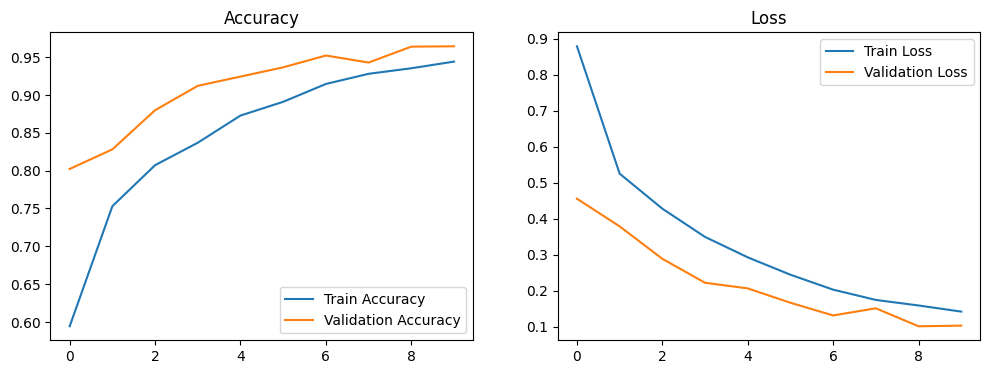

In [ ]:
# Training & Validation - History Visualization
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Loss')

    plt.show()

plot_history(history)


Step 5: Model Saving

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9643 - loss: 0.0987
Test Loss: 0.1007
Test Accuracy: 0.9639


In [ ]:
model = tf.keras.models.load_model('/content/alzheimers_detection_model.keras')


  step 6:New MRI Scan Processing

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
# Define class names
classes = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very Mild Dementia"]
def load_and_preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize
    return img_array


In [ ]:
image_path = '/content/ADNI_Dataset/Combined Dataset/train/Very Mild Impairment/VeryMildImpairment (1).jpg'
processed_image = load_and_preprocess_image(image_path)
prediction = model.predict(processed_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step


step-7)Detection Healthy or Demented

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Detection Result: Healthy


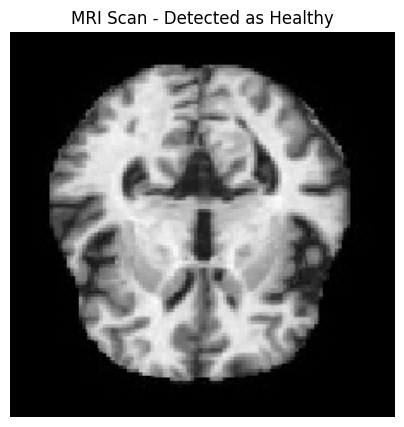

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Define class names
#classes = ["LMCI", "AD", "CN", "EMCI"]

# Load and preprocess the image
def load_and_preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Combined: Detection and Display
def detect_health(image_path):
    processed_image = load_and_preprocess_image(image_path)
    prediction = model.predict(processed_image)

    predicted_class_index = np.argmax(prediction)
    predicted_class = classes[predicted_class_index]
    detection_result = "Healthy" if predicted_class == "Non Demented" else "Demented"

    print("=" * 50)
    print(f"Detection Result: {detection_result}")
    print("=" * 50)

    img = image.load_img(image_path, target_size=(224, 224))
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("MRI Scan - Detected as " + detection_result)
    plt.show()

    return detection_result, predicted_class, prediction

  # Replace with your actual path
detection_result, predicted_class, prediction = detect_health(image_path)


step 8)classification[AD,EMCI,LMCI]

In [ ]:
# Classification - Identifying the Demented Stage
def classify_stage(predicted_class, prediction):
    confidence = np.max(prediction) * 100  # Extract confidence score
    class_mapping = {
        "Mild Dementia": "LMCI (Late Mild Cognitive Impairment)",
        "Moderate Dementia": "AD (Alzheimer's Disease)",
        "Very Mild Dementia": "EMCI (Early Mild Cognitive Impairment)"
    }
    final_stage = class_mapping.get(predicted_class, "Unknown")

    print("=" * 50)
    print(f"Original Predicted Class: {predicted_class}")
    print(f"Final Classification: {final_stage}")
    print(f"Confidence: {confidence:.2f}%")
    print("=" * 50)

    return final_stage, confidence
if detection_result == "Demented":
    final_stage, confidence = classify_stage(predicted_class, prediction)


classification-identify the demented stage

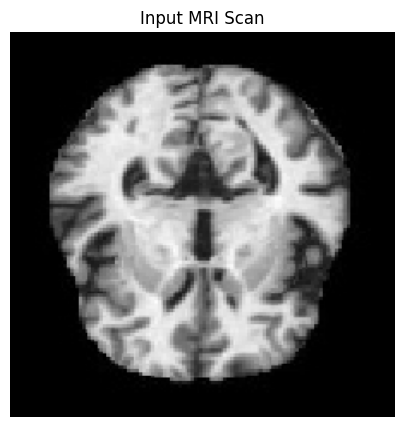

Final Classification Stage: CN (Cognitively Normal)


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def show_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input MRI Scan")
    plt.show()

def classification_stage(predicted_class):
    class_mapping = {
        "Mild Dementia": "LMCI (Late Mild Cognitive Impairment)",
        "Moderate Dementia": "AD (Alzheimer's Disease)",
        "Non Demented": "CN (Cognitively Normal)",
        "Very Mild Dementia": "EMCI (Early Mild Cognitive Impairment)"
    }
    final_stage = class_mapping.get(predicted_class, "Unknown")
    print(f"Final Classification Stage: {final_stage}")
    return final_stage
show_image(image_path)
final_stage = classification_stage(predicted_class)


step9)Affected Brain Region and Damage

In [ ]:
#Display the mri scan with Affected Regions
import cv2
import matplotlib.pyplot as plt

def load_and_display_image_with_regions(image_path, final_stage):
    if final_stage == "CN (Cognitively Normal)":
        return  # Skip both image and text output for CN

    # Load the image again for visualization (if Demented)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Define affected regions for each stage
    region_mapping = {
        "EMCI (Early Mild Cognitive Impairment)": ["Hippocampus", "Entorhinal Cortex"],
        "LMCI (Late Mild Cognitive Impairment)": ["Hippocampus", "Temporal Lobe"],
        "AD (Alzheimer's Disease)": ["Hippocampus", "Temporal Lobe", "Cerebral Cortex"]
    }

    affected_regions = region_mapping.get(final_stage, [])

    # Draw markers for affected regions
    if "Hippocampus" in affected_regions:
        cv2.circle(img, (112, 150), 15, (255, 0, 0), 2)

    if "Temporal Lobe" in affected_regions:
        cv2.rectangle(img, (60, 160), (160, 200), (0, 255, 0), 2)

    if "Entorhinal Cortex" in affected_regions:
        cv2.circle(img, (112, 170), 10, (255, 255, 0), 2)

    if "Cerebral Cortex" in affected_regions:
        cv2.rectangle(img, (5, 5), (219, 30), (255, 0, 255), 2)

    # Show the image with markings
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Affected Regions - {final_stage}")
    plt.show()

# Step Execution
load_and_display_image_with_regions(image_path, final_stage)


In [ ]:
def severity_assessment(final_stage):
    severity_mapping = {
        "CN (Cognitively Normal)": "Severity Level: 0 (No Impairment)",
        "EMCI (Early Mild Cognitive Impairment)": "Severity Level: 1 (very Mild Impairment)",
        "LMCI (Late Mild Cognitive Impairment)": "Severity Level: 2 (Mild Impairment)",
        "AD (Alzheimer's Disease)": "Severity Level: 3 (Modate Impairment)"
    }

    severity_level = severity_mapping.get(final_stage, "Severity Level: Not Available")

    print("Final Stage:", final_stage)
    print(severity_level)

    return severity_level

severity_level = severity_assessment(final_stage)


Final Stage: CN (Cognitively Normal)
Severity Level: 0 (No Impairment)


step 10) medication and suggestions

In [ ]:
def condition_assessment(final_stage):
    stage_details = {
        "CN (Cognitively Normal)": {
            "severity": "No Risk",
            "suggestions": [
                "Maintain a healthy lifestyle.",
                "Engage in regular physical exercise.",
                "Follow a brain-healthy diet rich in antioxidants and Omega-3.",
                "Stay socially active and engage in mental exercises."
            ]
        },
        "EMCI (Early Mild Cognitive Impairment)": {
            "severity": "Low Risk",
            "suggestions": [
                "Monitor cognitive function regularly.",
                "Adopt lifestyle changes such as exercise and diet.",
                "Participate in cognitive training programs.",
                "Consult a neurologist if symptoms worsen."
            ]
        },
        "LMCI (Late Mild Cognitive Impairment)": {
            "severity": "Moderate Risk",
            "suggestions": [
                "Schedule regular follow-ups with a neurologist.",
                "Consider medications if prescribed by a doctor.",
                "Use memory aids and family support for assistance.",
                "Cognitive therapy can help manage symptoms."
            ]
        },
        "AD (Alzheimer's Disease)": {
            "severity": "High Risk",
            "suggestions": [
                "Seek immediate medical attention.",
                "Medications may help manage symptoms.",
                "24/7 caregiver support may be needed.",
                "Make safety modifications at home.",
                "Consider support groups for family and caregivers."
            ]
        }
    }

    info = stage_details.get(final_stage, {
        "severity": "Unknown",
        "suggestions": ["Consult a healthcare professional for an accurate diagnosis."]
    })

    output_message = f"""
    Final Stage: {final_stage}
    Severity Level: {info['severity']}
    Suggestions:
    - """ + "\n    - ".join(info["suggestions"])

    print(output_message)

    return info

# Example usage
stage_info = condition_assessment(final_stage)



    Final Stage: CN (Cognitively Normal)
    Severity Level: No Risk
    Suggestions:
    - Maintain a healthy lifestyle.
    - Engage in regular physical exercise.
    - Follow a brain-healthy diet rich in antioxidants and Omega-3.
    - Stay socially active and engage in mental exercises.


confusion matrix

64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Classification Report:
              precision    recall  f1-score   support

          AD       0.99      0.98      0.98       512
          CN       1.00      1.00      1.00       512
        EMCI       0.91      0.96      0.94       512
        LMCI       0.96      0.92      0.94       512

    accuracy                           0.96      2048
   macro avg       0.97      0.96      0.96      2048
weighted avg       0.97      0.96      0.96      2048



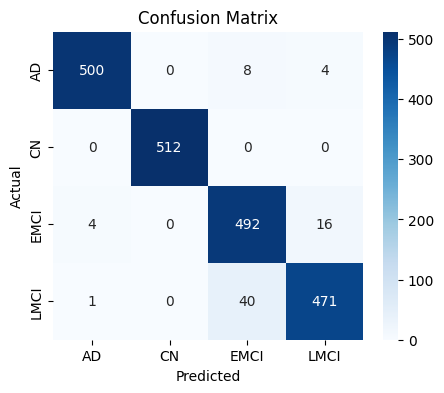

In [ ]:
y_true = np.argmax(test_labels, axis=1)

predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
classes = ['AD', 'CN', 'EMCI', 'LMCI']
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
!pip install pywhatkit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.2/171.2 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for pyautogui: filename=pyautogui-0.9.54-py3-none-any.whl size=37684 sha256=17e73be70b61c85

In [ ]:
import pywhatkit as pwk

# Condition Assessment
def condition_assessment(final_stage, phone_number):
    stage_details = {
        "CN (Cognitively Normal)": {
            "severity": "No Risk",
            "suggestions": [
                "Maintain a healthy lifestyle.",
                "Engage in regular physical exercise.",
                "Follow a brain-healthy diet rich in antioxidants and Omega-3.",
                "Stay socially active and engage in mental exercises."
            ]
        },
        "EMCI (Early Mild Cognitive Impairment)": {
            "severity": "Low Risk",
            "suggestions": [
                "Monitor cognitive function regularly.",
                "Adopt lifestyle changes such as exercise and diet.",
                "Participate in cognitive training programs.",
                "Consult a neurologist if symptoms worsen."
            ]
        },
        "LMCI (Late Mild Cognitive Impairment)": {
            "severity": "Moderate Risk",
            "suggestions": [
                "Schedule regular follow-ups with a neurologist.",
                "Consider medications if prescribed by a doctor.",
                "Use memory aids and family support for assistance.",
                "Cognitive therapy can help manage symptoms."
            ]
        },
        "AD (Alzheimer's Disease)": {
            "severity": "High Risk",
            "suggestions": [
                "Seek immediate medical attention.",
                "Medications may help manage symptoms.",
                "24/7 caregiver support may be needed.",
                "Make safety modifications at home.",
                "Consider support groups for family and caregivers."
            ]
        }
    }

    info = stage_details.get(final_stage, {
        "severity": "Unknown",
        "suggestions": ["Consult a healthcare professional for an accurate diagnosis."]
    })

    output_message = f"""
    📜 Alzheimer's Condition Report 📜
    -----------------------------------
    Patient's Condition Assessment
    -----------------------------------
    📝 Stage: {final_stage}
     Severity Level: {info['severity']}
     Suggestions:
    - """ + "\n    - ".join(info["suggestions"])

    print(output_message)

    # Define the WhatsApp message
    whatsapp_message = f"""
    📜 Alzheimer's Condition Report 📜
    -----------------------------------
     Patient's Condition Assessment
    -----------------------------------
    📝 Stage: {final_stage}
     Severity Level: {info['severity']}
     Suggestions:
    - """ + "\n    - ".join(info["suggestions"])

    # Send the WhatsApp message
    try:
        pwk.sendwhatmsg_instantly(phone_number, whatsapp_message, wait_time=15, tab_close=True)
        print("WhatsApp message sent successfully!")
    except Exception as e:
        print(f"An error occurred while sending WhatsApp message: {e}")

    return info

# Example usage
# Assuming final_stage is obtained from the 20th step
# final_stage = "LMCI (Late Mild Cognitive Impairment)"  # This line is just for illustration
phone_number = "+918247751317"  # Replace with the recipient's phone number
condition_assessment(final_stage, phone_number)

KeyError: 'DISPLAY'

In [ ]:
import pywhatkit as kit
from datetime import datetime
import time


In [ ]:
def send_whatsapp_report(user_phone, final_stage, stage_info):
    # Format the message
    report_text = (
        f"🧠 Alzheimer's Condition Assessment 🧠\n"
        f"-----------------------------------\n"
        f"📝 Stage: {final_stage}\n"
        f"⚠️ Severity: {stage_info['severity']}\n"
        f"💡 Suggestions:\n- " + "\n- ".join(stage_info['suggestions']) +
        "\n\nStay healthy and take care! 🏥"
    )

    # Get the current time and set the message to send 1 minute later
    now = datetime.now()
    hour = now.hour
    minute = now.minute + 1  # Send after 1 minute

    print(f"📨 Sending message to {user_phone} at {hour}:{minute}...")

    # Send WhatsApp message
    kit.sendwhatmsg(user_phone, report_text, hour, minute)

    print("✅ Message sent successfully!")


In [ ]:
# Define the user's phone number (with country code)
user_phone = "+918247751317"  # Replace with actual number

# Example stage (use actual detected stage from your model)
final_stage = "EMCI (Early Mild Cognitive Impairment)"

# Get stage details
stage_info = condition_assessment(final_stage)

# Send WhatsApp message
send_whatsapp_report(user_phone, final_stage, stage_info)


In [ ]:
!pip install gradio tensorflow numpy matplotlib opencv-python


In [ ]:
#working good
import numpy as np
import tensorflow as tf
import cv2
import gradio as gr
from tensorflow.keras.preprocessing import image

# Load the trained model
model_path = "alzheimers_detection_model.keras"
model = tf.keras.models.load_model(model_path)

# Define class names
classes = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very Mild Dementia"]

# Helper function to classify the stage
def classify_stage(predicted_class):
    class_mapping = {
        "Mild Dementia": "LMCI (Late Mild Cognitive Impairment)",
        "Moderate Dementia": "AD (Alzheimer's Disease)",
        "Non Demented": "CN (Cognitively Normal)",
        "Very Mild Dementia": "EMCI (Early Mild Cognitive Impairment)"
    }
    return class_mapping.get(predicted_class, "Unknown")

# Helper function to assess the condition
def condition_assessment(final_stage):
    stage_details = {
        "CN (Cognitively Normal)": {
            "severity": "No Risk",
            "suggestions": [
                "Maintain a healthy lifestyle.",
                "Engage in regular physical exercise.",
                "Follow a brain-healthy diet rich in antioxidants and Omega-3.",
                "Stay socially active and engage in mental exercises."
            ]
        },
        "EMCI (Early Mild Cognitive Impairment)": {
            "severity": "Low Risk",
            "suggestions": [
                "Monitor cognitive function regularly.",
                "Adopt lifestyle changes such as exercise and diet.",
                "Participate in cognitive training programs.",
                "Consult a neurologist if symptoms worsen."
            ]
        },
        "LMCI (Late Mild Cognitive Impairment)": {
            "severity": "Moderate Risk",
            "suggestions": [
                "Schedule regular follow-ups with a neurologist.",
                "Consider medications if prescribed by a doctor.",
                "Use memory aids and family support for assistance.",
                "Cognitive therapy can help manage symptoms."
            ]
        },
        "AD (Alzheimer's Disease)": {
            "severity": "High Risk",
            "suggestions": [
                "Seek immediate medical attention.",
                "Medications may help manage symptoms.",
                "24/7 caregiver support may be needed.",
                "Make safety modifications at home.",
                "Consider support groups for family and caregivers."
            ]
        }
    }
    return stage_details.get(final_stage, {
        "severity": "Unknown",
        "suggestions": ["Consult a healthcare professional for an accurate diagnosis."]
    })

# Helper function to display image with affected regions
def load_and_display_image_with_regions(image, final_stage):
    img = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))

    region_mapping = {
        "EMCI (Early Mild Cognitive Impairment)": ["Hippocampus", "Entorhinal Cortex"],
        "LMCI (Late Mild Cognitive Impairment)": ["Hippocampus", "Temporal Lobe"],
        "AD (Alzheimer's Disease)": ["Hippocampus", "Temporal Lobe", "Cerebral Cortex"]
    }

    affected_regions = region_mapping.get(final_stage, [])

    if "Hippocampus" in affected_regions:
        cv2.circle(img, (112, 150), 15, (255, 0, 0), 2)

    if "Temporal Lobe" in affected_regions:
        cv2.rectangle(img, (60, 160), (160, 200), (0, 255, 0), 2)

    if "Entorhinal Cortex" in affected_regions:
        cv2.circle(img, (112, 170), 10, (255, 255, 0), 2)

    if "Cerebral Cortex" in affected_regions:
        cv2.rectangle(img, (5, 5), (219, 30), (255, 0, 255), 2)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Prediction function for Gradio
def predict_image(image):
    # Preprocess the image
    img_array = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_array = cv2.resize(img_array, (224, 224))
    img_array = img_array.astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make a prediction
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class = classes[predicted_class_index]
    confidence = np.max(prediction) * 100

    # Get the final stage and suggestions
    final_stage = classify_stage(predicted_class)
    stage_info = condition_assessment(final_stage)

    # Prepare the output message
    output_message = f"""
    📜 Alzheimer's Condition Report 📜
    -----------------------------------
     Patient's Condition Assessment
    -----------------------------------
    📝 Stage: {final_stage}
     Severity Level: {stage_info['severity']}
     Suggestions:
    - """ + "\n    - ".join(stage_info["suggestions"])

    # Display the image with affected regions
    img_with_regions = load_and_display_image_with_regions(image, final_stage)

    return final_stage, "\n".join(stage_info["suggestions"]), f"{confidence:.2f}%", img_with_regions, output_message

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(label="MRI Scan"),
    outputs=[
        gr.Textbox(label="Stage"),
        gr.Textbox(label="Suggestions"),
        gr.Textbox(label="Confidence"),
        gr.Image(label="Affected Areas"),
        gr.Textbox(label="Report")
    ],
    title="Alzheimer's Disease Detection",
    description="Upload an MRI scan to detect the stage of Alzheimer's disease and get suggestions."
)

# Launch the Gradio interface
iface.launch()

In [ ]:
import pywhatkit as pwk
#working good
# Condition Assessment
def condition_assessment(final_stage, phone_number):
    stage_details = {
        "CN (Cognitively Normal)": {
            "severity": "No Risk",
            "suggestions": [
                "Maintain a healthy lifestyle.",
                "Engage in regular physical exercise.",
                "Follow a brain-healthy diet rich in antioxidants and Omega-3.",
                "Stay socially active and engage in mental exercises."
            ]
        },
        "EMCI (Early Mild Cognitive Impairment)": {
            "severity": "Low Risk",
            "suggestions": [
                "Monitor cognitive function regularly.",
                "Adopt lifestyle changes such as exercise and diet.",
                "Participate in cognitive training programs.",
                "Consult a neurologist if symptoms worsen."
            ]
        },
        "LMCI (Late Mild Cognitive Impairment)": {
            "severity": "Moderate Risk",
            "suggestions": [
                "Schedule regular follow-ups with a neurologist.",
                "Consider medications if prescribed by a doctor.",
                "Use memory aids and family support for assistance.",
                "Cognitive therapy can help manage symptoms."
            ]
        },
        "AD (Alzheimer's Disease)": {
            "severity": "High Risk",
            "suggestions": [
                "Seek immediate medical attention.",
                "Medications may help manage symptoms.",
                "24/7 caregiver support may be needed.",
                "Make safety modifications at home.",
                "Consider support groups for family and caregivers."
            ]
        }
    }

    info = stage_details.get(final_stage, {
        "severity": "Unknown",
        "suggestions": ["Consult a healthcare professional for an accurate diagnosis."]
    })

    output_message = f"""
    📜 Alzheimer's Condition Report 📜
    -----------------------------------
    Patient's Condition Assessment
    -----------------------------------
    📝 Stage: {final_stage}
     Severity Level: {info['severity']}
     Suggestions:
    - """ + "\n    - ".join(info["suggestions"])

    print(output_message)

    # Define the WhatsApp message
    whatsapp_message = f"""
    📜 Alzheimer's Condition Report 📜
    -----------------------------------
     Patient's Condition Assessment
    -----------------------------------
    📝 Stage: {final_stage}
     Severity Level: {info['severity']}
     Suggestions:
    - """ + "\n    - ".join(info["suggestions"])

    # Send the WhatsApp message
    try:
        pwk.sendwhatmsg_instantly(phone_number, whatsapp_message, wait_time=15, tab_close=True)
        print("WhatsApp message sent successfully!")
    except Exception as e:
        print(f"An error occurred while sending WhatsApp message: {e}")

    return info

# Example usage
# Assuming final_stage is obtained from the 20th step
# final_stage = "LMCI (Late Mild Cognitive Impairment)"  # This line is just for illustration
phone_number = "+918247751317"  # Replace with the recipient's phone number
condition_assessment(final_stage, phone_number)